In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib widget

# from dataio.mts import get_data_single_mjd, mjd2utc, get_gts_single_mjd
from cmpmaker.runner import calc
# from cmpa.calc import (
#     calc_nodes_ratio,
# )
from timanda.gtserie import GTserie
from dataio.mts import get_data_single_mjd, mjd2utc, get_gts_single_mjd, set_flags_in_area

from cmpa.calc import calc_nodes_ratio

In [2]:
mjd = 60760

## Clean

In [ ]:
dataset = "comb_hydro_698_notrack"
# set_flags_in_area(dataset, 60760, 44587400.1, 60761, 1e10, 1)
# set_flags_in_area(dataset, 60760, 44587500.06, 60761, 1e10, 0)
# set_flags_in_area(dataset, 60760, 44587499.98, 60761, -1e10, 0)

/home/stront/svnSr/progs/timanda/timanda/gtserie.py:122: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


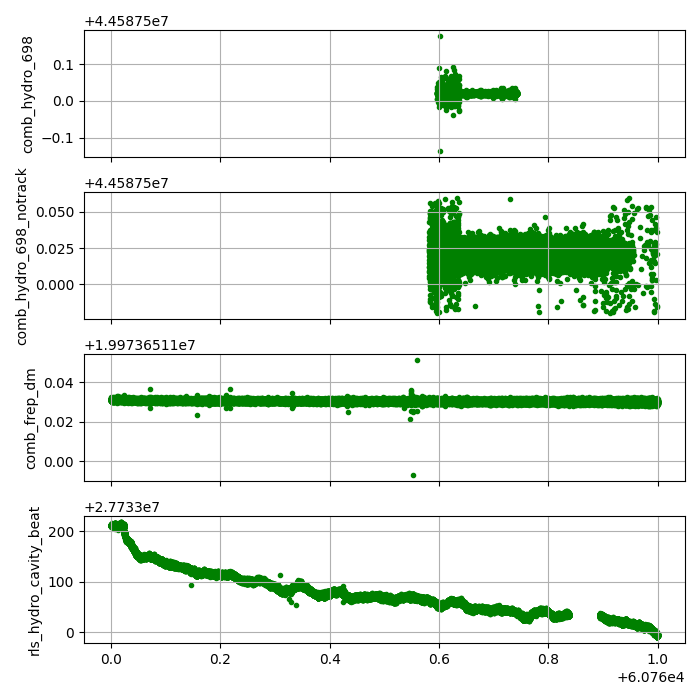

(<Figure size 700x700 with 4 Axes>,
 array([<Axes: ylabel='comb_hydro_698'>,
        <Axes: ylabel='comb_hydro_698_notrack'>,
        <Axes: ylabel='comb_frep_dm'>,
        <Axes: ylabel='rls_hydro_cavity_beat'>], dtype=object))

In [4]:
gts = get_gts_single_mjd(
        datasets=["comb_hydro_698", "comb_hydro_698_notrack", "comb_frep_dm", "rls_hydro_cavity_beat",], 
        mjd=mjd, allowed_flag=1,
        from_mjd=mjd,
        to_mjd=mjd+1,
    )
gts.plot()
# gts, cmm = gts.align_all_to_grid_zoh_and_drop_missing(start_mjd=mjd, stop_mjd=mjd+1)

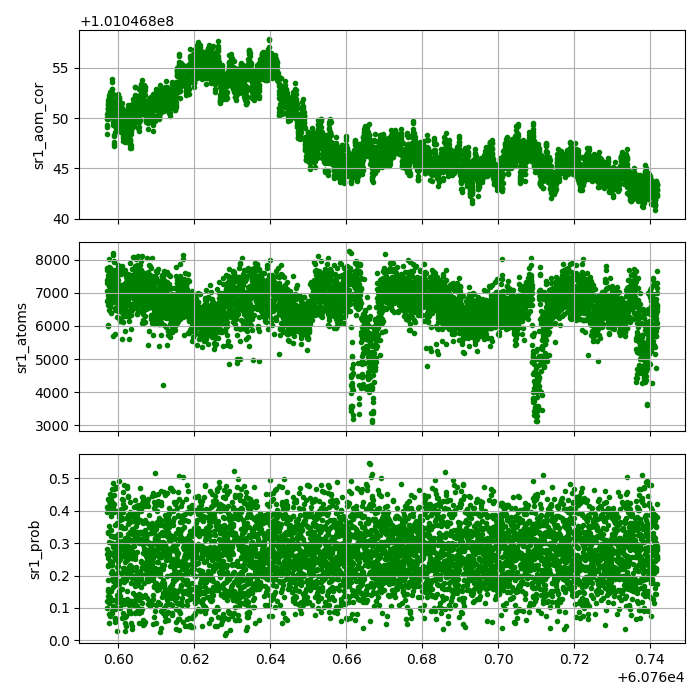

In [5]:
gts = get_gts_single_mjd(
        datasets=[                  
                    "sr1_aom_cor",
                  "sr1_atoms",
                  "sr1_prob",
                #   "intensity_698_PD"
                  ], 
        mjd=mjd, allowed_flag=1,
        from_mjd=mjd,
        to_mjd=mjd+1,
    )
gts.plot()
gts, cmm = gts.align_all_to_grid_zoh_and_drop_missing(start_mjd=mjd, stop_mjd=mjd+1)

# Calculate sr comparator

In [3]:
out = calc(
    "comparators.UMK_LO-UMK_Sr1",
    from_mjd=mjd,
    to_mjd=mjd+1-1e-8,
    plot=False,
    output_file="result.npz",
)

Calculating 'comparators.UMK_LO-UMK_Sr1' from MJD 60760 to 60760.99999999
logical_name=comparators.UMK_LO-UMK_Sr1
Found change points: []
Built segments: [(60760, 60760.99999999)]
Temporary run dir: /tmp/cmpmaker_run_zlq7dfk8
Loaded segment file: /tmp/cmpmaker_run_zlq7dfk8/segment_000_60760_60760p99999999.npz


In [4]:
gts = GTserie.load_npz('result.npz')
# gts.plot(mts_names=['fc_aom','mfc','DAB'])

### create sr comparator file

In [5]:
date_str = mjd2utc(mjd, strfmt='%Y-%m-%d')
print(date_str)
gts.create_comparator_file(
    filename=f'../tock_data/UMK_LO-UMK_Sr1/{date_str}_UMK_LO-UMK_Sr1.dat',
    # filename=f'{date_str}_UMK_LO-UMK_Sr1.dat',
    mts_names=['DAB', 'valid', 'uncert'],
    headers=['A->B', 'flag', 'relative systematic uncertainty'],
    formats=['.6f', '.0f', '.4e'],
)

2025-03-26


## Compare in network


[PATH] edges:
PTB_Sr3_CombKnoten <--> PTB_Si   (1): PTB_Si-PTB_Sr3_CombKnoten
PTB_Si <--> PTB_NIRP   (1): PTB_Si-PTB_NIRP
PTB_NIRP <--> PTB_RLS   (1): PTB_NIRP-PTB_RLS
PTB_RLS <--> UMK_RLS   (1): PTB_RLS-UMK_RLS
UMK_RLS <--> UMK_LO   (1): UMK_LO-UMK_RLS
UMK_LO <--> UMK_Sr1   (1): UMK_LO-UMK_Sr1

[LOAD] Creating GTserie and loading MTSeries:
 - PTB_Si-PTB_Sr3_CombKnoten
 - PTB_Si-PTB_NIRP
 - PTB_NIRP-PTB_RLS
 - PTB_RLS-UMK_RLS
 - UMK_LO-UMK_RLS
 - UMK_LO-UMK_Sr1


/home/stront/svnSr/progs/timanda/timanda/gtserie.py:122: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


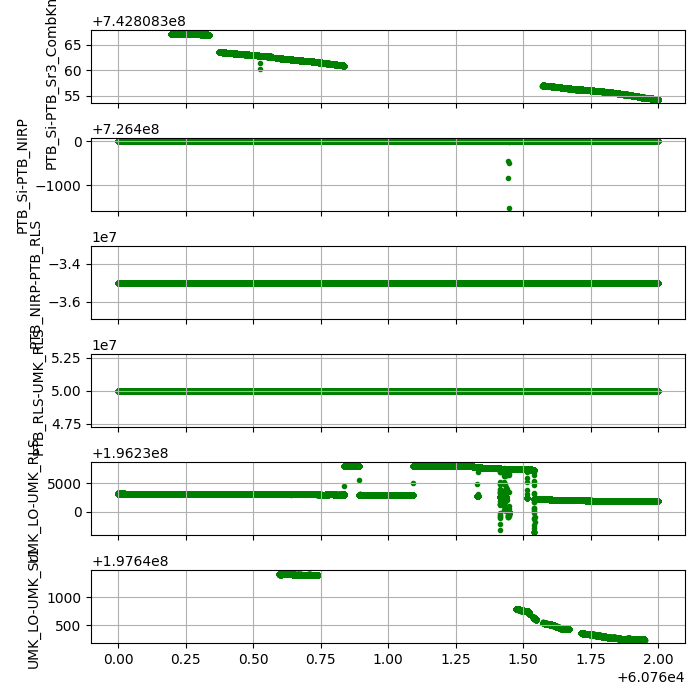



[MODEL] nu0_ref = nu0(PTB_Sr3_CombKnoten) = 4.292280e+14 Hz
[STEP] 
	PTB_Sr3_CombKnoten->PTB_Si: 'PTB_Si-PTB_Sr3_CombKnoten' (forward), 
	rho0_yaml=4.5290614331838680e-01, rho0_step(path)=4.5290614331838680e-01, 
	prod_prev(after)=4.5290614331838680e-01, scale=5.144033e-15
[STEP] 
	PTB_Si->PTB_NIRP: 'PTB_Si-PTB_NIRP' (reverse), 
	rho0_yaml=1.0000000000000000e+00, rho0_step(path)=1.0000000000000000e+00, 
	prod_prev(after)=4.5290614331838680e-01, scale=-5.144033e-15
[STEP] 
	PTB_NIRP->PTB_RLS: 'PTB_NIRP-PTB_RLS' (reverse), 
	rho0_yaml=1.0000000000000000e+00, rho0_step(path)=1.0000000000000000e+00, 
	prod_prev(after)=4.5290614331838680e-01, scale=-5.144033e-15
[STEP] 
	PTB_RLS->UMK_RLS: 'PTB_RLS-UMK_RLS' (reverse), 
	rho0_yaml=1.0000000000000000e+00, rho0_step(path)=1.0000000000000000e+00, 
	prod_prev(after)=4.5290614331838680e-01, scale=-5.144033e-15
[STEP] 
	UMK_RLS->UMK_LO: 'UMK_LO-UMK_RLS' (forward), 
	rho0_yaml=1.0000000000000000e+00, rho0_step(path)=1.0000000000000000e+00, 
	prod_

In [6]:
mts = calc_nodes_ratio(
        fmjd=mjd,
        tmjd=mjd+1,
        start_node='PTB_Sr3_CombKnoten',
        # start_node='OBSPARIS_SrL',
        # goal_node='PTB_Sr3_CombKnoten',
        goal_node='UMK_Sr1',
    )

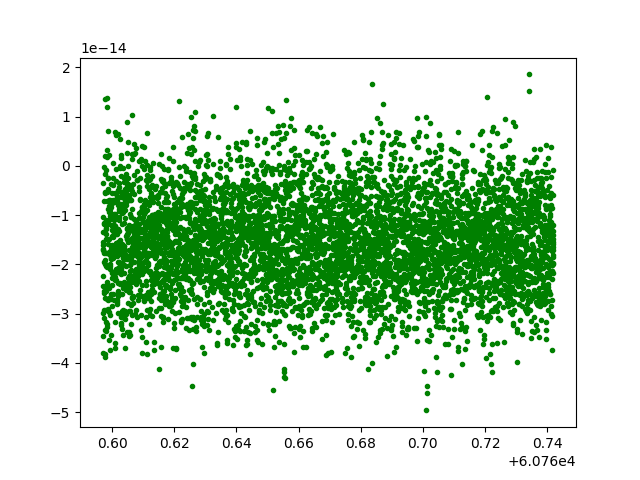

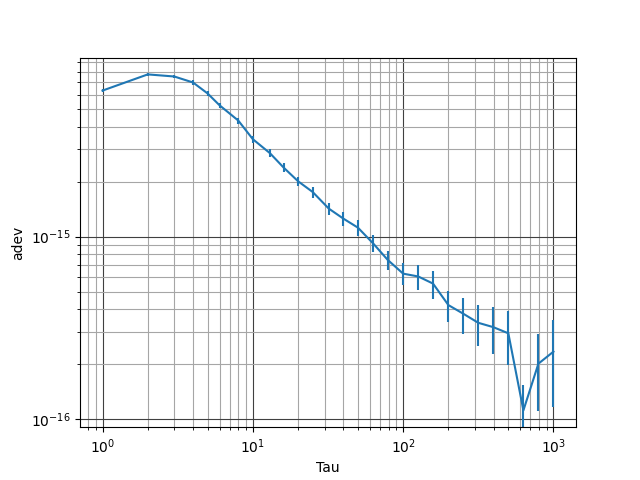

-1.566978144389688e-14


In [7]:
# rmts = mts.resample(period_s=1200)
mts = mts.getrange(mjd, mjd+1)
mts.rm_area(mjd, 6e-14, mjd+1, 1)
mts.rm_area(mjd, -6e-14, mjd+1, -1)
mts.plot()
mts.plot_allan()
print(mts.mean())
# rmts.plot()